# Notebook for Training and Saving Final Augmented Model

In [2]:
from google.colab import drive
from google.colab import files
drive.mount('/content/drive')

import shutil
import zipfile
import os

shutil.copy("/content/drive/MyDrive/DLProjectData/RoCoLeDataset.zip", "/content/RoCoLeDataset.zip")
shutil.copy("/content/drive/MyDrive/DLProjectData/CLRDataset.zip", "/content/CLRDataset.zip")

with zipfile.ZipFile("/content/RoCoLeDataset.zip", 'r') as zip_ref:
    zip_ref.extractall("/content/RoCoLeDataset_Local")
    
with zipfile.ZipFile("/content/CLRDataset.zip", 'r') as zip_ref:
    zip_ref.extractall("/content/CLRDataset_Local")
    
clean_data_path = "/content/RoCoLeDataset_Local/RoCoLeDataset"
messy_data_path = "/content/CLRDataset_Local/CLRDataset"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
from torchvision import transforms, datasets, models
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split
import time
import matplotlib.pyplot as plt

torch.manual_seed(123)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

#Baseline normalization and validation transformation

base_post_transforms = [
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
]

val_transforms = transforms.Compose([
    transforms.Resize((384, 384)),
    *base_post_transforms
])

Using device: cuda:0


In [4]:
import albumentations as A
from albumentations.pytorch import ToTensorV2
import numpy as np

class AlbumentationsWrapper:
    def __init__(self, transform):
        self.transform = transform

    def __call__(self, img):
        img = np.array(img)
        augmented = self.transform(image=img)
        return augmented['image']
    
dense_experiment = {
        
    "Full Model Augmentations (Color Jitter, Rotation, Shadow, Blur, Noise, Brightness, and Cropping)": AlbumentationsWrapper(A.Compose([
        A.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4, hue=0, p=1.0),
        A.Rotate(limit=45, p=0.5),
        A.RandomShadow(p=0.5),
        A.GaussianBlur(p=0.2),
        A.GaussNoise(p=0.3),
        A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
        A.RandomResizedCrop(size=(384, 384), scale=(0.3, 1), p=1.0),
        A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ToTensorV2()
    ]))
}

In [5]:
from torch.utils.data import ConcatDataset

def get_dataloaders(train_transform):
    """Creates dataloaders combining 80% clean and 90% messy data for training."""
    
    full_train_clean = datasets.ImageFolder(clean_data_path, transform=train_transform)
    full_val_clean = datasets.ImageFolder(clean_data_path, transform=val_transforms)

    clean_targets = full_train_clean.targets
    clean_train_idx, clean_val_idx = train_test_split(
        range(len(clean_targets)), test_size=0.20, random_state=42, stratify=clean_targets 
    )
    clean_train_subset = Subset(full_train_clean, clean_train_idx)
    clean_val_subset = Subset(full_val_clean, clean_val_idx)

    messy_temp = datasets.ImageFolder(root=messy_data_path)
    def binary_target_transform(label_idx):
        class_name = messy_temp.classes[label_idx]
        return 0 if class_name == '0' else 1

    full_train_messy = datasets.ImageFolder(
        messy_data_path, transform=train_transform, target_transform=binary_target_transform
    )
    full_eval_messy = datasets.ImageFolder(
        messy_data_path, transform=val_transforms, target_transform=binary_target_transform
    )

    messy_mapped_targets = [binary_target_transform(t) for t in messy_temp.targets]
    messy_train_idx, messy_eval_idx = train_test_split(
        range(len(messy_mapped_targets)), test_size=0.20, random_state=42, stratify=messy_mapped_targets
    )
    messy_train_subset = Subset(full_train_messy, messy_train_idx)
    messy_eval_subset = Subset(full_eval_messy, messy_eval_idx)

    combined_train_dataset = ConcatDataset([clean_train_subset, messy_train_subset])
    
    train_loader = DataLoader(combined_train_dataset, batch_size=128, shuffle=True, num_workers=2)
    test_loader = DataLoader(clean_val_subset, batch_size=128, shuffle=False, num_workers=2)
    eval_loader = DataLoader(messy_eval_subset, batch_size=128, shuffle=False, num_workers=2)

    return train_loader, test_loader, eval_loader, len(combined_train_dataset), len(clean_val_subset), len(messy_eval_subset)

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
from torchvision import models

def train_evaluate_model(train_loader, test_loader, eval_loader, train_size, val_size, eval_size, num_epochs=20):
    """Initializes and trains a DenseNet201 model with fine-tuning on the later layers."""
    model = models.densenet201(weights=models.DenseNet201_Weights.DEFAULT)
    for name, param in model.named_parameters():
        if "features.denseblock4" in name or "features.norm5" in name:
            param.requires_grad = True
        else:
            param.requires_grad = False

    num_classes = model.classifier.in_features
    model.classifier = nn.Linear(num_classes, 2) 
    model = model.to(device)


    criterion = nn.CrossEntropyLoss()
    params_to_update = [p for p in model.parameters() if p.requires_grad]
    optimizer = optim.Adam(params_to_update, lr=0.0001)
    scheduler = lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=4)

    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [],   'val_acc': [],
        'drive_loss': [], 'drive_acc': []
    }
    
    for epoch in range(num_epochs):
        for phase in ['train', 'val', 'drive']:
            if phase == 'train':
                model.train() 
                dataloader, dataset_size = train_loader, train_size
            elif phase == 'val':
                model.eval() 
                dataloader, dataset_size = test_loader, val_size
            else:
                model.eval()
                dataloader, dataset_size = eval_loader, eval_size

            running_corrects = 0
            running_loss = 0.0

            for inputs, labels in dataloader:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / dataset_size
            epoch_acc = running_corrects.double() / dataset_size

            if phase == 'train':
                history['train_loss'].append(epoch_loss)
                history['train_acc'].append(epoch_acc.cpu().item()) 
            elif phase == 'val':
                val_epoch_loss = epoch_loss
                history['val_loss'].append(epoch_loss)
                history['val_acc'].append(epoch_acc.cpu().item())
            else:
                history['drive_loss'].append(epoch_loss)
                history['drive_acc'].append(epoch_acc.cpu().item())

        if epoch % 5 == 0:
            print(f"Epoch {epoch}: Train Accuracy: {history['train_acc'][-1]:.4f}, Validation Accuracy: {history['val_acc'][-1]:.4f}, External Accuracy: {history['drive_acc'][-1]:.4f} ")
        scheduler.step(val_epoch_loss)
        
    return model, history

In [7]:
all_histories = {}
num_epochs_to_run = 40

aug_name, transform = next(iter(dense_experiment.items()))
print(f"\n{'-'*40}")
print(f"Training Large Model with: {aug_name}")
print(f"{'-'*40}")
    
train_dl, val_dl, eval_dl, t_size, v_size, e_size = get_dataloaders(transform)
    
start_time = time.time()
trained_model, history = train_evaluate_model(
        train_dl, val_dl, eval_dl, 
        t_size, v_size, e_size, 
        num_epochs=num_epochs_to_run
    )
time_elapsed = time.time() - start_time
    
print(f"Completed {aug_name} in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s")
all_histories[aug_name] = history


----------------------------------------
Training Large Model with: Full Model Augmentations (Color Jitter, Rotation, Shadow, Blur, Noise, Brightness, and Cropping)
----------------------------------------
Downloading: "https://download.pytorch.org/models/densenet201-c1103571.pth" to /root/.cache/torch/hub/checkpoints/densenet201-c1103571.pth


100%|██████████| 77.4M/77.4M [00:00<00:00, 170MB/s] 


Epoch 0: Train Accuracy: 0.8180, Validation Accuracy: 0.8710, External Accuracy: 0.9964 
Epoch 5: Train Accuracy: 0.9461, Validation Accuracy: 0.9534, External Accuracy: 1.0000 
Epoch 10: Train Accuracy: 0.9473, Validation Accuracy: 0.9570, External Accuracy: 1.0000 
Epoch 15: Train Accuracy: 0.9568, Validation Accuracy: 0.9534, External Accuracy: 1.0000 
Epoch 20: Train Accuracy: 0.9666, Validation Accuracy: 0.9570, External Accuracy: 1.0000 
Epoch 25: Train Accuracy: 0.9622, Validation Accuracy: 0.9570, External Accuracy: 1.0000 
Epoch 30: Train Accuracy: 0.9660, Validation Accuracy: 0.9570, External Accuracy: 1.0000 
Epoch 35: Train Accuracy: 0.9640, Validation Accuracy: 0.9570, External Accuracy: 1.0000 
Completed Full Model Augmentations (Color Jitter, Rotation, Shadow, Blur, Noise, Brightness, and Cropping) in 52m 16s


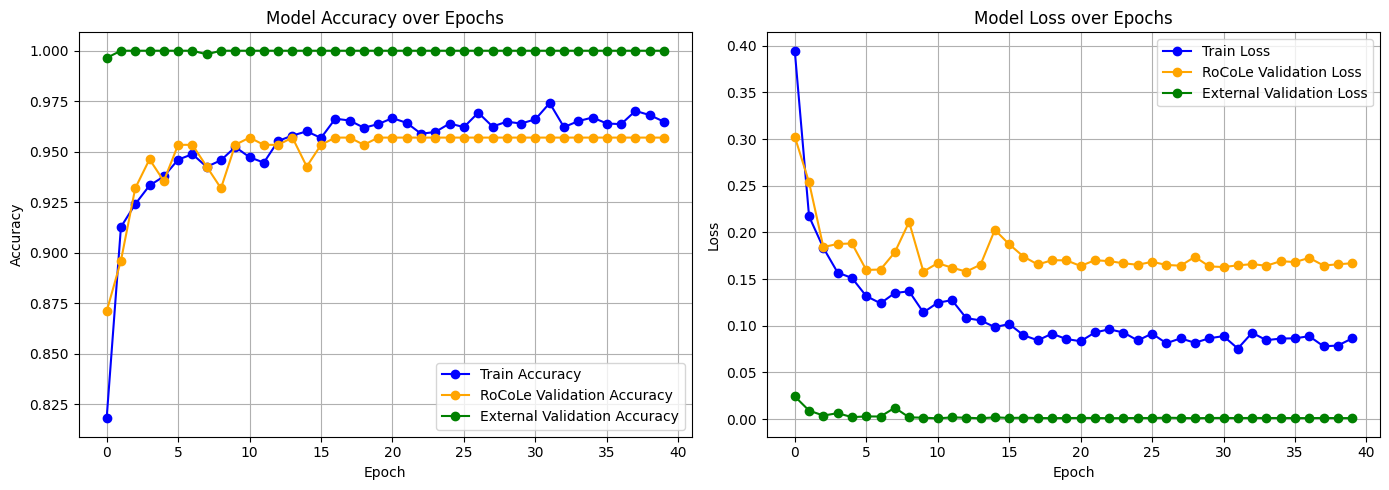

In [14]:
import matplotlib.pyplot as plt
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

#Accuracy
ax1.plot(history['train_acc'], label='Train Accuracy', color='blue', marker='o')
ax1.plot(history['val_acc'], label='RoCoLe Validation Accuracy', color='orange', marker='o')
ax1.plot(history['drive_acc'], label='External Validation Accuracy', color='green', marker='o')
ax1.set_title('Model Accuracy over Epochs')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

#Loss
ax2.plot(history['train_loss'], label='Train Loss', color='blue', marker='o')
ax2.plot(history['val_loss'], label='RoCoLe Validation Loss', color='orange', marker='o')
ax2.plot(history['drive_loss'], label='External Validation Loss', color='green', marker='o')
ax2.set_title('Model Loss over Epochs')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

In [12]:
#Run to save model
model_path = '/content/drive/My Drive/densenet_clr_parameters.pth'
torch.save(trained_model.state_dict(), model_path)

In [ ]:
print(f"Final Accuracy Values\n Train: {100*history['train_acc'][-1]:.2f}%\n Validation: {100*history['val_acc'][-1]:.2f}%\n External Validation: {100*history['drive_acc'][-1]:.2f}%")

Final Accuracy Values
 Train: 96.48%
 Validation: 95.70%
 External: 100.00%
